## 1. Data cleaning and pre-processing

In [1]:
import pandas as pd
 
ferryterminal_el_demand = pd.read_excel("inputs/ferryterminal_el_demand.xlsx")

In [2]:
# Take first two columns, exclude first data row after header,
# rename columns, and parse datetime
ferryterminal_el_demand = (
    ferryterminal_el_demand.iloc[1:, [0, 1]]
      .copy()
      .rename(columns={ferryterminal_el_demand.columns[0]: "datetime", ferryterminal_el_demand.columns[1]: "ampere"})
)
ferryterminal_el_demand["datetime"] = pd.to_datetime(
    ferryterminal_el_demand["datetime"], errors="coerce"
)
ferryterminal_el_demand["ampere"] = pd.to_numeric(
    ferryterminal_el_demand["ampere"], errors="coerce"
)

In [3]:
ferryterminal_el_demand.head()

,datetime,ampere
1,2025-03-01 00:15:00,3.533
2,2025-03-01 00:30:00,3.567
3,2025-03-01 00:45:00,3.582
4,2025-03-01 01:00:00,3.692
5,2025-03-01 01:15:00,3.704


In [4]:
ferryterminal_el_demand.tail()

,datetime,ampere
35035,2026-02-28 22:45:00,2.605
35036,2026-02-28 23:00:00,2.567
35037,2026-02-28 23:15:00,2.594
35038,2026-02-28 23:30:00,2.658
35039,2026-02-28 23:45:00,2.542


Since the given dataset is from March 2025 to February 2026, the January and February 2026 data is taken and shifted at the beginning of the dataset as it was 2025.

In [5]:
# Build a Jan-Dec 2025 series by moving Jan/Feb 2026 to Jan/Feb 2025
df_months_shift = ferryterminal_el_demand.copy()

mask_jan_feb_2026 = (
    (df_months_shift["datetime"].dt.year == 2026) &
    (df_months_shift["datetime"].dt.month.isin([1, 2]))
)

# Jan/Feb 2026 -> Jan/Feb 2025
part_jf_2025 = df_months_shift.loc[mask_jan_feb_2026].copy()
part_jf_2025["datetime"] = part_jf_2025["datetime"] - pd.DateOffset(years=1)

# Keep Mar-Dec 2025
part_mar_dec_2025 = df_months_shift.loc[
    (df_months_shift["datetime"].dt.year == 2025) &
    (df_months_shift["datetime"].dt.month >= 3)
].copy()

# Final dataset: Jan 2025 ... Dec 2025
ferryterminal_el_demand = (
    pd.concat([part_jf_2025, part_mar_dec_2025], ignore_index=True)
      .sort_values("datetime")
      .reset_index(drop=True)
)

# Optional quick checks
print(ferryterminal_el_demand["datetime"].min())
print(ferryterminal_el_demand["datetime"].max())
print(ferryterminal_el_demand["datetime"].dt.year.value_counts())

2025-01-01 00:00:00
2025-12-31 23:45:00
datetime
2025    35039
Name: count, dtype: int64


Converting to kWh for visualization

In [6]:
ferryterminal_el_demand_hourly = (
    ferryterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .resample("h")["ampere"]
    .sum()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(0.25) # convert to kWh
    .reset_index()
    .rename(columns={"ampere": "energy_kWh"})
)

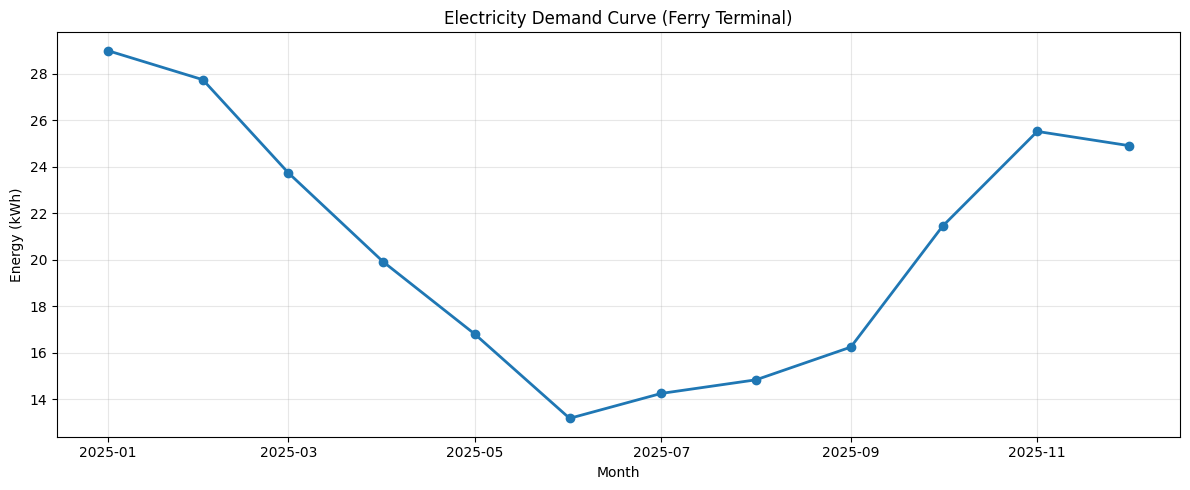

In [7]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = ferryterminal_el_demand_hourly.dropna(subset=["datetime", "energy_kWh"]).copy()
df_plot = df_plot.set_index("datetime").sort_index()

# Monthly demand curve (average energy per month)
monthly_curve = df_plot["energy_kWh"].resample("MS").mean()  # MS = month start

plt.figure(figsize=(12, 5))
plt.plot(monthly_curve.index, monthly_curve.values, marker="o", linewidth=2)
plt.title("Electricity Demand Curve (Ferry Terminal)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

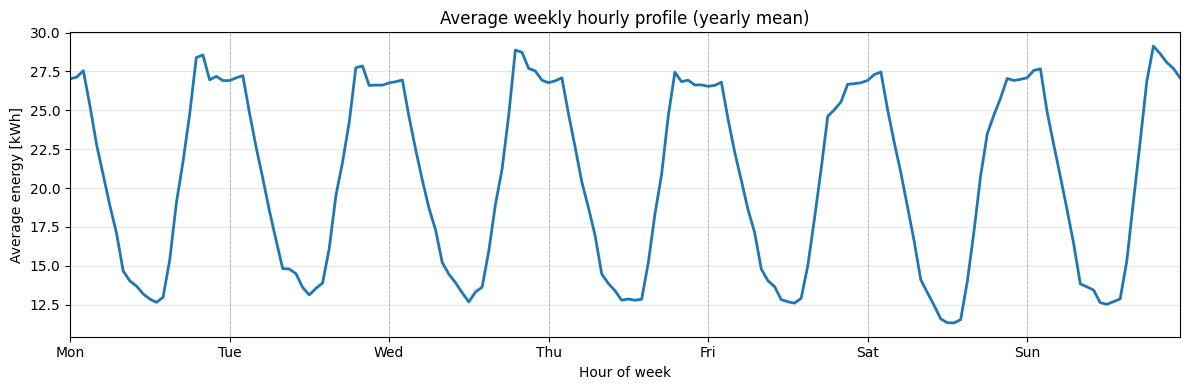

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = ferryterminal_el_demand_hourly.copy()

# 1) Ensure datetime type
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# 2) Build hour-of-week index: Monday 00:00 = 0, ..., Sunday 23:00 = 167
df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour

# 3) Yearly average profile per hour-of-week (168 points)
weekly_profile = (
    df.groupby("hour_of_week")["energy_kWh"]
      .mean()
      .reindex(range(168))  # keep full week order
      .reset_index(name="avg_energy_kWh")
)

# 4) Plot one-week average hourly profile
plt.figure(figsize=(12, 4))
plt.plot(weekly_profile["hour_of_week"], weekly_profile["avg_energy_kWh"], linewidth=2)

# Day separators and labels
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Average energy [kWh]")
plt.title("Average weekly hourly profile (yearly mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converting to kW

In [9]:
from math import sqrt


ferryterminal_power_demand = (
    ferryterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(5000/1630) # scaling factor given by different floor areas of the existing and new terminal (5000 m2 vs 1630 m2)
    .mul(sqrt(3)) # sqrt of 3 because of 3-phase system
    .reset_index()
    .rename(columns={"ampere": "power_kW"})
)

ferryterminal_power_demand.head()


,datetime,power_kW
0,2025-01-01 00:00:00,182.160208
1,2025-01-01 00:15:00,182.008787
2,2025-01-01 00:30:00,183.472529
3,2025-01-01 00:45:00,182.866843
4,2025-01-01 01:00:00,180.393623


In [10]:
DT_H = 0.25  # 15 min

check = ferryterminal_power_demand[["datetime", "power_kW"]].copy()
check["datetime"] = pd.to_datetime(check["datetime"], errors="coerce")
check["power_kW"] = pd.to_numeric(check["power_kW"], errors="coerce")
check = check.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

check["energy_kWh"] = check["power_kW"] * DT_H

n_timesteps = len(check)

idx_max = check["power_kW"].idxmax()
idx_min = check["power_kW"].idxmin()

summary = pd.DataFrame(
    [
        {
            "timesteps": n_timesteps,
            "datetime": check.loc[idx_max, "datetime"],
            "kW": check.loc[idx_max, "power_kW"],
            "kWh": check.loc[idx_max, "energy_kWh"],
        },
        {
            "timesteps": n_timesteps,
            "datetime": check.loc[idx_min, "datetime"],
            "kW": check.loc[idx_min, "power_kW"],
            "kWh": check.loc[idx_min, "energy_kWh"],
        },
        {
            "timesteps": n_timesteps,
            "datetime": pd.NaT,
            "kW": check["power_kW"].mean(),
            "kWh": check["energy_kWh"].mean(),
        },
        {
            "timesteps": n_timesteps,
            "datetime": pd.NaT,
            "kW": check["power_kW"].sum(),
            "kWh": check["energy_kWh"].sum(),
        },
    ],
    index=["max", "min", "mean", "total"],
)

summary

,timesteps,datetime,kW,kWh
max,35039,2025-02-15 19:00:00,3.202567e+02,80.064181
min,35039,2025-10-16 05:30:00,0.000000e+00,0.000000
mean,35039,NaT,1.093674e+02,27.341858
total,35039,NaT,3.832126e+06,958031.376180


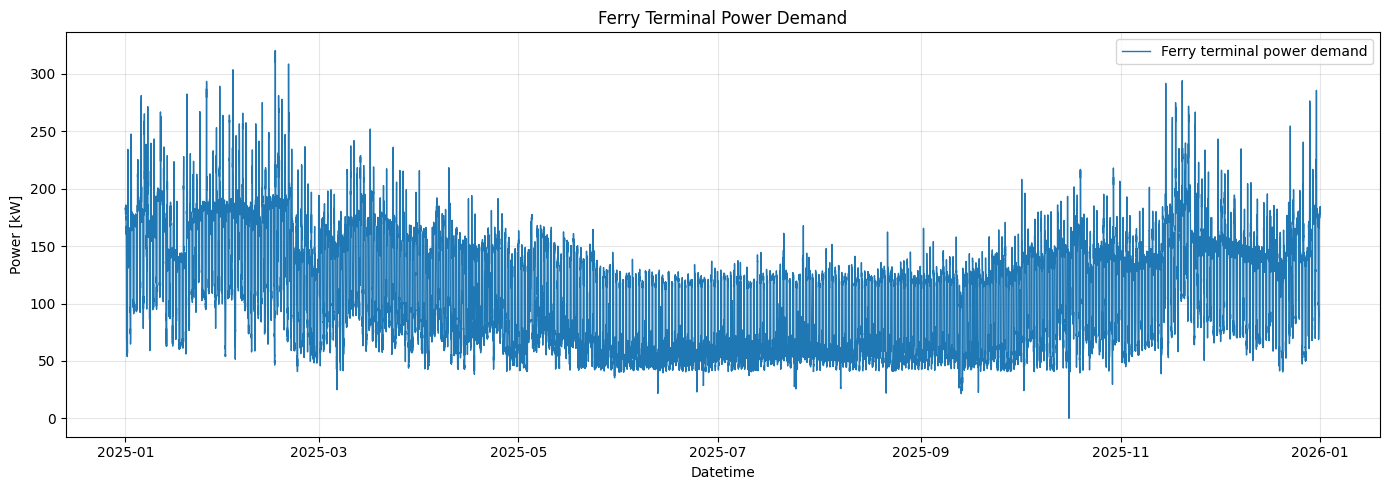

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime is parsed and sorted
df_plot = ferryterminal_power_demand.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot["datetime"], df_plot["power_kW"], linewidth=1.0, label="Ferry terminal power demand")
plt.title("Ferry Terminal Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Ships schedule and consumptions

In [12]:
import pandas as pd

# Read Excel and keep only first 3 columns
ships_schedule = pd.read_excel("inputs/passenger_ship_data_Oskarshamn_2025.xlsx").iloc[:, [0, 2, 3]].copy()
ships_schedule.columns = ["ship_name", "arrival_dt", "departure_dt"]

# Parse datetime columns
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"])
ships_schedule["departure_dt"] = pd.to_datetime(ships_schedule["departure_dt"])

# Keep schedule as-is (no month/year shifting)
ships_schedule = ships_schedule.sort_values("arrival_dt").reset_index(drop=True)

ships_schedule.head()

,ship_name,arrival_dt,departure_dt
0,VISBY,2025-01-01 19:15:00,2025-01-01 20:10:00
1,VISBY,2025-01-02 20:00:00,2025-01-02 21:05:00
2,VISBY,2025-01-03 19:15:00,2025-01-03 20:10:00
3,VISBY,2025-01-04 10:40:00,2025-01-04 19:50:00
4,VISBY,2025-01-05 19:15:00,2025-01-05 20:10:00


In [13]:
ships_schedule.tail()

,ship_name,arrival_dt,departure_dt
448,GOTLAND,2025-12-26 19:15:00,2025-12-26 20:10:00
449,GOTLAND,2025-12-27 10:55:00,2025-12-28 11:30:00
450,GOTLAND,2025-12-28 19:15:00,2025-12-28 20:10:00
451,GOTLAND,2025-12-29 20:00:00,2025-12-29 21:05:00
452,VISBY,2025-12-30 20:00:00,2025-12-30 21:05:00


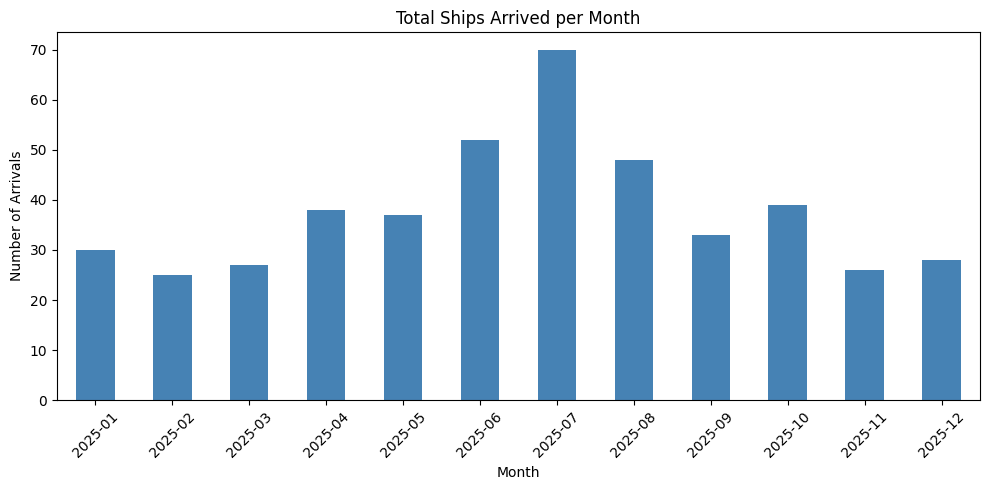

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"], errors="coerce")

# Count arrivals per month
monthly_arrivals = (
    ships_schedule
    .dropna(subset=["arrival_dt"])
    .groupby(ships_schedule["arrival_dt"].dt.to_period("M"))
    .size()
    .rename("arrivals")
)

# Plot
ax = monthly_arrivals.plot(kind="bar", figsize=(10, 5), color="steelblue")
ax.set_title("Total Ships Arrived per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

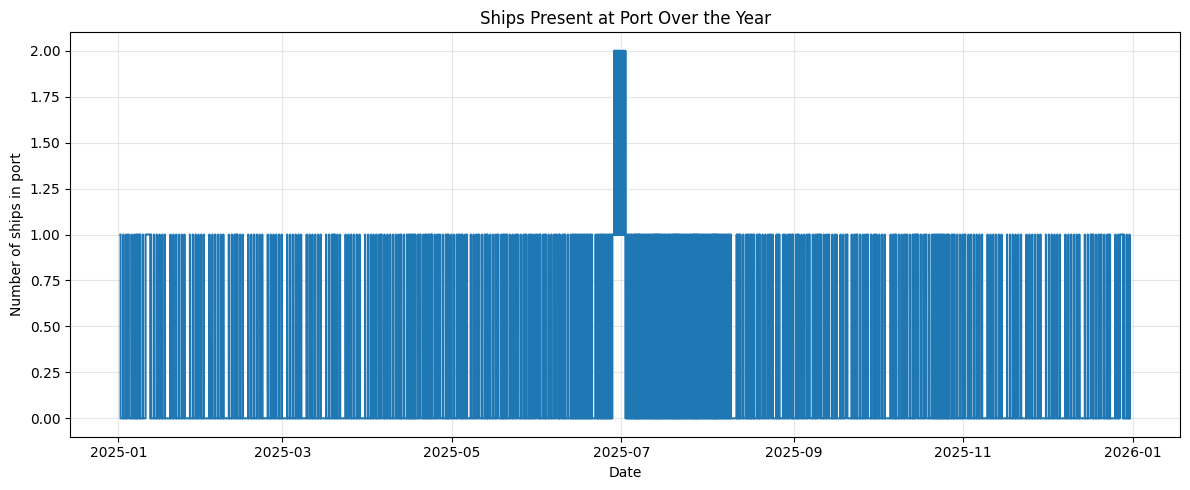

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only valid stays
df = ships_schedule.dropna(subset=["arrival_dt", "departure_dt"]).copy()
df = df[df["departure_dt"] >= df["arrival_dt"]].copy()

# Build +1 event at arrival and -1 event at departure
events = pd.concat([
    df[["arrival_dt"]].rename(columns={"arrival_dt": "time"}).assign(delta=1),
    df[["departure_dt"]].rename(columns={"departure_dt": "time"}).assign(delta=-1),
], ignore_index=True)

# Sort events and compute number of ships in port
events = events.sort_values("time").reset_index(drop=True)
events["ships_in_port"] = events["delta"].cumsum()

# Plot
plt.figure(figsize=(12, 5))
plt.step(events["time"], events["ships_in_port"], where="post")
plt.title("Ships Present at Port Over the Year")
plt.xlabel("Date")
plt.ylabel("Number of ships in port")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd

# Expected input table: one row per ferry stay with:
# - arrival_dt
# - departure_dt
# - ship_name
# Example source variable: ships_schedule

# 1) Prepare intervals
ships_intervals = ships_schedule[["arrival_dt", "departure_dt", "ship_name"]].copy()
ships_intervals["arrival_dt"] = pd.to_datetime(ships_intervals["arrival_dt"])
ships_intervals["departure_dt"] = pd.to_datetime(ships_intervals["departure_dt"])

# Power by ship (kW)
power_map_kw = {
    "VISBY": 1492,
    "GOTLAND": 1494,
    "DROTTEN": 1368,
}
ships_intervals["power_kw"] = ships_intervals["ship_name"].astype(str).str.upper().map(power_map_kw).fillna(900.0)

# 1b) Snap to 15-minute steps (00, 15, 30, 45)
# - arrivals -> previous step (floor)
# - departures -> next step (ceil)
ships_intervals["arrival_dt"] = ships_intervals["arrival_dt"].dt.floor("15min")
ships_intervals["departure_dt"] = ships_intervals["departure_dt"].dt.ceil("15min")

# Optional: drop invalid intervals
ships_intervals = ships_intervals[ships_intervals["departure_dt"] > ships_intervals["arrival_dt"]]

# 2) Define 15-minute window from data
start_step = ships_intervals["arrival_dt"].min().floor("15min")
end_step = ships_intervals["departure_dt"].max().ceil("15min")
step_edges = pd.date_range(start=start_step, end=end_step, freq="15min")

# 3) Build 15-minute occupancy matrix
step_index = step_edges[:-1]
start_col = ships_intervals["arrival_dt"].to_numpy()[:, None]
end_col = ships_intervals["departure_dt"].to_numpy()[:, None]
mask = (step_index.to_numpy()[None, :] >= start_col) & (step_index.to_numpy()[None, :] < end_col)

# Per-ship power multipliers by position in stay:
# - if stay <= 4h: first 15 min = 0.85, last 15 min = 0.85
# - if stay  > 4h:
#   - first 15 min after arrival: 0.425
#   - second 15 min after arrival: 0.85
#   - second-last 15 min before departure: 0.85
#   - last 15 min before departure: 0.425
factors = mask.astype(float)
max_steps_short_stay = int(pd.Timedelta(hours=4) / pd.Timedelta(minutes=15))  # 16 steps

for i in range(factors.shape[0]):
    active_idx = np.flatnonzero(mask[i])
    if active_idx.size == 0:
        continue

    if active_idx.size <= max_steps_short_stay:
        # Short stay profile
        factors[i, active_idx[0]] = 0.85
        factors[i, active_idx[-1]] = 0.85
        continue

    # Long stay profile
    # Arrival ramp
    factors[i, active_idx[0]] = 0.425
    factors[i, active_idx[1]] = 0.85

    # Departure ramp
    factors[i, active_idx[-1]] = 0.425
    factors[i, active_idx[-2]] = 0.85

# When multiple ships overlap, only the latest-arrived stay is energized
arrivals = ships_intervals["arrival_dt"].to_numpy()
active_counts = mask.sum(axis=0)

for j in range(mask.shape[1]):
    if active_counts[j] <= 1:
        continue

    active_rows = np.flatnonzero(mask[:, j])
    winner = active_rows[np.argmax(arrivals[active_rows])]
    factors[active_rows[active_rows != winner], j] = 0.0

# Demand per step = sum(power_kW * factor of active ships)
step_energy_kwh = (factors * ships_intervals["power_kw"].to_numpy()[:, None]).sum(axis=0)

# 4) Final dataset: ships_demand
ships_demand = pd.DataFrame({"datetime": step_index, "demand_kW": step_energy_kwh})

ships_demand.head()

,datetime,demand_kW
0,2025-01-01 19:15:00,1268.2
1,2025-01-01 19:30:00,1492.0
2,2025-01-01 19:45:00,1492.0
3,2025-01-01 20:00:00,1268.2
4,2025-01-01 20:15:00,0.0


In [17]:
ships_demand.max()

datetime     2025-12-30 21:00:00
demand_kW                 1494.0
dtype: object

In [18]:
# Rebuild clean occupancy time series first
events_clean = (
    events.groupby("time", as_index=True)["delta"]
    .sum()
    .sort_index()
    .to_frame()
)
events_clean["ships_in_port"] = events_clean["delta"].cumsum().clip(lower=0)

# Hourly time series (every hour in the year)
hourly_presence = events_clean["ships_in_port"].resample("1h").ffill()

# 1) Average by hour of day (0..23)
avg_by_hour = hourly_presence.groupby(hourly_presence.index.hour).mean()
avg_by_hour.index.name = "hour"

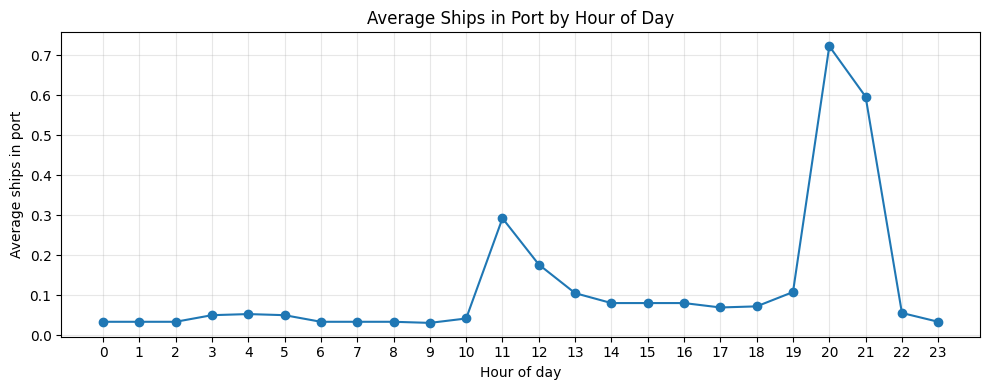

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
avg_by_hour.plot(marker="o")
plt.title("Average Ships in Port by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average ships in port")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Optimization using Gurobi

In [20]:
port_operations = pd.read_excel("inputs/Port_Operations.xlsx")
HM_consumptions_full = pd.read_excel("inputs/HM_consumptions_15minutes.xlsx")

Reads price in EUR/MWh and converts them to SEK (1 EUR = 10.77 SEK) and EUR/kWh

In [21]:
# Read CSV from inputs and keep first + fourth columns
da_price = pd.read_excel("inputs/dayahedprices_15min.xlsx").copy()

da_price.head()

,datetime,da_price
0,2025-01-01 00:00:00,0.034111
1,2025-01-01 00:15:00,0.033426
2,2025-01-01 00:30:00,0.034068
3,2025-01-01 00:45:00,0.034528
4,2025-01-01 01:00:00,0.026369


Only taking ferry terminal related vehicles

In [22]:
import pandas as pd

# Normalize all column names in HM_consumptions
HM = HM_consumptions_full.copy()
HM.columns = (
    HM.columns.astype(str)
    .str.replace("\xa0", "", regex=False)   # remove NBSP
    .str.replace(r"\s+", " ", regex=True)   # normalize repeated spaces
    .str.strip()                            # trim edges
)

selected_cols = [
    "Term.drag 468",
    "Term.drag 469",
    "Term.drag 470",
    "Lastmaskin 430",
    "Lastmaskin 431",
    "Lastmaskin 432",
    "Truck 417",
    "Truck 413",
    "Truck 420",
    "Truck 422",
    "Truck 423",
    "Truck 424",
]

# Keep datetime if present
keep = ["datetime"] + selected_cols

# Optional safety check
missing = [c for c in keep if c not in HM.columns]
print("Missing:", missing)

# Final filtered dataframe
HM_consumptions_ferryterminal = HM[[c for c in keep if c in HM.columns]].copy()

Missing: []


In [23]:
import numpy as np
import pandas as pd

# -----------------------------
# Assumed existing in notebook:
# - ferryterminal_power_demand: columns ["datetime", "power_kW"]
# - HM_consumptions: columns ["datetime", <vehicle IDs...>] (kWh per hour)
# - port_operations: columns ["ID", "Battery Capacity (kWh)", "Fast Charge Capacity (kW)",
#                             "Requires charging during operation"]
# -----------------------------

# --- Time set T (15-minute) built from ferry terminal + ships demand in kW ---
# ferryterminal_power_demand expected columns: ["datetime", "power_kW"]
base_kw = ferryterminal_power_demand[["datetime", "power_kW"]].copy()
base_kw["datetime"] = pd.to_datetime(base_kw["datetime"], errors="coerce")
base_kw["power_kW"] = pd.to_numeric(base_kw["power_kW"], errors="coerce")
base_kw = (
    base_kw
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# ships_demand expected to provide one of: demand_kW, demand_kWh, demand_mwh, energy_kWh
ships_kw = ships_demand.copy()
ships_kw["datetime"] = pd.to_datetime(ships_kw["datetime"], errors="coerce")

if "demand_kW" in ships_kw.columns:
    ships_kw["ships_kW"] = pd.to_numeric(ships_kw["demand_kW"], errors="coerce")

ships_kw = (
    ships_kw[["datetime", "ships_kW"]]
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# Merge timestep-by-timestep at 15-minute resolution
full_idx = pd.date_range(
    start=min(base_kw["datetime"].min(), ships_kw["datetime"].min()),
    end=max(base_kw["datetime"].max(), ships_kw["datetime"].max()),
    freq="15min"
)

T_df = (
    pd.DataFrame({"datetime": full_idx})
    .merge(base_kw, on="datetime", how="left")
    .merge(ships_kw, on="datetime", how="left")
)
T_df["power_kW"] = T_df["power_kW"].fillna(0.0)
T_df["ships_kW"] = T_df["ships_kW"].fillna(0.0)
T_df["total_kW"] = T_df["power_kW"] + T_df["ships_kW"]

T = T_df["datetime"].to_list()

# Fixed terminal demand D[t] in kW
D_kw = T_df.set_index("datetime")["total_kW"].to_dict()

# Helpful index maps
t2i = {t: i for i, t in enumerate(T)}
i2t = {i: t for t, i in t2i.items()}

# --- Vehicle set V from port_operations (Step 24=C) ---
po = port_operations.copy()
po["ID"] = po["ID"].astype(str)

# drop duplicates just in case
po = po.drop_duplicates(subset=["ID"], keep="first").set_index("ID")

V = po.index.to_list()

# Vehicle parameters
Cap_kwh = po["Battery Capacity (kWh)"].astype(float).to_dict()

eligible = (
    po["Requires charging during operation"]
    .notna()
    .to_dict()
)

Pfast_kw = po["Fast Charge Capacity (kW)"].astype(float).fillna(0.0).to_dict()

# --- Consumption Econs[v,t] (kWh) aligned to V x T ---
hm = HM_consumptions_ferryterminal.copy()
hm["datetime"] = pd.to_datetime(hm["datetime"])
hm = hm.dropna(subset=["datetime"]).drop_duplicates(subset=["datetime"]).set_index("datetime").sort_index()

# Reindex to T and ensure all vehicles exist as columns (missing -> 0)
hm = hm.reindex(T, fill_value=0.0)
for v in V:
    if v not in hm.columns:
        hm[v] = 0.0

# Keep only vehicles in V (extra columns ignored)
hm = hm[V].astype(float)

# Dict keyed by (v,t) for easy modeling
Econs_kwh = {(v, t): float(hm.loc[t, v]) for t in T for v in V}

# --- Time window masks ---
slow_hours = {20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6}   # do NOT include 7
fast_hours = {9, 12, 15}                              # 9-10, 12-13, 15-16

is_slow = {t: (t.hour in slow_hours) for t in T}
is_fast = {t: (t.hour in fast_hours) for t in T}
is_allowed = {t: (is_slow[t] or is_fast[t]) for t in T}

T07 = [t for t in T if (t.hour == 7 and t.minute == 0)]

# --- Sanity checks ---
print(f"|T| = {len(T)} 15 minutes steps from {T[0]} to {T[-1]}")
print(f"|V| = {len(V)} vehicles")
print(f"07:00 checkpoints in T: {len(T07)}")
print(f"Allowed charging hours in T: {sum(is_allowed.values())} (slow={sum(is_slow.values())}, fast={sum(is_fast.values())})")

# Verify no consumption after 20:00 (per your assumption)
after20 = [(v, t, Econs_kwh[(v, t)]) for t in T if t.hour >= 20 for v in V if Econs_kwh[(v, t)] > 0]
print(f"Consumption entries with hour>=20 and >0 kWh: {len(after20)}")
if after20:
    print("Example:", after20[0])

|T| = 35040 15 minutes steps from 2025-01-01 00:00:00 to 2025-12-31 23:45:00
|V| = 32 vehicles
07:00 checkpoints in T: 365
Allowed charging hours in T: 20440 (slow=16060, fast=4380)
Consumption entries with hour>=20 and >0 kWh: 0


In [24]:
from gurobipy import GRB

# -----------------------------
# Uses objects created earlier:
# T, V, t2i, i2t
# D_kw, Cap_kwh, eligible, Pfast_kw
# Econs_kwh
# is_slow, is_fast, is_allowed
# T07
# -----------------------------

P_slow = 22.0  # kW
dt = 0.25      # hour (15-minute timestep)
FAST_LIMIT = 4
SOC_MIN_FRAC = 0.10
SOC_MAX_FRAC = 1.0
INTRADAY_SOC_SKIP_FRAC = 0.50

# Precompute index helpers
T_idx = list(range(len(T)))
T07_i = sorted(t2i[t] for t in T07)
T07_set = set(T07_i)

next_07_by_i = {}
next_07 = None
for i in reversed(T_idx):
    if i in T07_set:
        next_07 = i
    next_07_by_i[i] = next_07


class DummyVar:
    def __init__(self, x=0.0):
        self.X = float(x)


class DummyModel:
    def __init__(self):
        self.Status = GRB.OPTIMAL
        self.SolCount = 1


# Keep same interface as Gurobi vars used by downstream cells
P = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
SOC = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
m = DummyModel()

# Start at the minimum SOC; 07:00 full charge must be earned through charging.
soc_now = {v: float(Cap_kwh[v]) * SOC_MAX_FRAC for v in V}


def _remaining_day_consumption(v, i):
    day = i2t[i].date()
    return sum(
        float(Econs_kwh[(v, i2t[k])])
        for k in range(i, len(T_idx))
        if i2t[k].date() == day
    )


def _can_finish_daily_schedule(v, i):
    cap = float(Cap_kwh[v])
    min_soc = cap * SOC_MIN_FRAC
    return soc_now[v] - _remaining_day_consumption(v, i) >= min_soc - 1e-9


def _skip_intraday_charging(v, i):
    # Skip all intraday charging, including slow-rate charging in fast windows.
    if not is_fast[i2t[i]]:
        return False

    cap = float(Cap_kwh[v])
    return (
        soc_now[v] > cap * INTRADAY_SOC_SKIP_FRAC
        and _can_finish_daily_schedule(v, i)
    )


def _future_consumption(v, i_start, i_end):
    return sum(float(Econs_kwh[(v, i2t[k])]) for k in range(i_start, i_end))


def _remaining_charge_slots(v, i_start, i_end):
    return [
        k
        for k in range(i_start, i_end)
        if is_allowed[i2t[k]] and float(Econs_kwh[(v, i2t[k])]) <= 0.0
    ]


for i in T_idx:
    t = i2t[i]

    # SOC is stored at start of timestep i
    for v in V:
        SOC[v, i].X = soc_now[v]

    if i in T07_set:
        for v in V:
            target_soc = float(Cap_kwh[v]) * SOC_MAX_FRAC
            if soc_now[v] < target_soc - 1e-6:
                raise RuntimeError(
                    f"Vehicle {v} reached {soc_now[v]:.3f} kWh at {t}, "
                    f"below the 07:00 target of {target_soc:.3f} kWh."
                )

    # Choose which eligible vehicles get fast slots this timestep.
    # Dumb rule: among vehicles that can charge now, prioritize biggest energy deficit.
    fast_candidates = []
    if is_fast[t] and is_allowed[t]:
        for v in V:
            cons = float(Econs_kwh[(v, t)])
            cap = float(Cap_kwh[v])
            target_soc = cap * SOC_MAX_FRAC
            if (
                eligible.get(v, False)
                and cons <= 0.0
                and soc_now[v] < target_soc - 1e-9
                and not _skip_intraday_charging(v, i)
            ):
                fast_candidates.append((target_soc - soc_now[v], v))

    fast_candidates.sort(reverse=True)
    fast_set = {v for _, v in fast_candidates[:FAST_LIMIT]}

    # Earliest-possible charging, with extra push before the next 07:00 checkpoint.
    for v in V:
        cap = float(Cap_kwh[v])
        min_soc = cap * SOC_MIN_FRAC
        target_soc = cap * SOC_MAX_FRAC
        cons = float(Econs_kwh[(v, t)])

        if (not is_allowed[t]) or (cons > 0.0):
            p_cap = 0.0
        elif is_slow[t]:
            p_cap = P_slow
        elif is_fast[t]:
            if eligible.get(v, False) and (v in fast_set):
                p_cap = float(Pfast_kw.get(v, P_slow))
            else:
                p_cap = P_slow
        else:
            p_cap = 0.0

        if is_fast[t] and _skip_intraday_charging(v, i):
            p_cap = 0.0

        max_by_headroom = max(0.0, (target_soc - soc_now[v]) / dt)
        p = min(p_cap, max_by_headroom)

        next07 = next_07_by_i.get(i)
        if next07 is not None and i < next07 and p > 0.0:
            future_cons = _future_consumption(v, i, next07)
            shortfall_energy = target_soc - (soc_now[v] - future_cons)
            if shortfall_energy > 1e-9:
                remaining_slots = _remaining_charge_slots(v, i, next07)
                if remaining_slots:
                    p_needed = shortfall_energy / (dt * len(remaining_slots))
                    p = min(p_cap, max_by_headroom, max(p, p_needed))

        P[v, i].X = float(p)

        soc_next = soc_now[v] + p * dt - cons
        soc_now[v] = min(target_soc, max(min_soc, soc_next))

# Diagnostics similar to old cell
p_peak = max(float(D_kw[i2t[i]]) + sum(P[v, i].X for v in V) for i in T_idx)
total_energy = sum(P[v, i].X * dt for v in V for i in T_idx)

if m.Status == GRB.OPTIMAL:
    print("P_peak (kW):", float(p_peak))
    print("Total charged energy (kWh):", float(total_energy))
    print(f"07:00 SOC checkpoints enforced: {len(T07_i)}")
else:
    print("Scheduler status:", m.Status)

P_peak (kW): 2322.7709789871733
Total charged energy (kWh): 398065.0
07:00 SOC checkpoints enforced: 365


In [25]:
# Build timestamp -> price mapping aligned to model timesteps T
price_df = da_price.copy()
price_df["datetime"] = pd.to_datetime(price_df["datetime"], errors="coerce").dt.tz_localize(None)
price_df["da_price"] = pd.to_numeric(price_df["da_price"], errors="coerce")

price_series = (
    price_df.dropna(subset=["datetime", "da_price"])
            .sort_values("datetime")
            .drop_duplicates("datetime", keep="last")
            .set_index("datetime")["da_price"]
)

t_index = pd.DatetimeIndex(pd.to_datetime(T)).tz_localize(None)
price_on_T = price_series.reindex(t_index).ffill().bfill()

if price_on_T.isna().any():
    missing = list(price_on_T[price_on_T.isna()].index[:10])
    raise ValueError(f"Missing da_price for timestamps (examples): {missing}")

price_t = {t: float(v) for t, v in zip(T, price_on_T.values)}

In [26]:
total_charging_cost = sum(
    P[v, i].X * dt * price_t[i2t[i]]
    for v in V
    for i in T_idx
)

print("Total charging cost:", (float(1.0561*total_charging_cost)+float(0.025*total_energy)))

Total charging cost: 213172.85203039265


In [48]:
import pandas as pd

DT_H = 0.25

def compute_peak_impact_metrics(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    load_no = df["base_demand_kw"] + df["shore_power_demand_kw"]
    load_with = df["total_kW"]
    ev_kw = df["EV_charging_kw"] if "EV_charging_kw" in df.columns else (load_with - load_no)

    idx_peak_with = load_with.idxmax()

    peak_no = float(load_no.max())
    peak_with = float(load_with.max())

    return {
        "peak_no_charging_kw": peak_no,
        "peak_with_charging_kw": peak_with,
        "peak_increase_kw": peak_with - peak_no,
        "ev_kw_at_system_peak": float(ev_kw.loc[idx_peak_with]),
    }


if "df_opt" not in globals():
    df_opt = pd.read_excel("outputs/dumb_ferryterminal_loadshifting.xlsx")

peak_summary = compute_peak_impact_metrics(df_opt)
print(peak_summary)

{'peak_no_charging_kw': 1796.4899222484617, 'peak_with_charging_kw': 2322.7709789871733, 'peak_increase_kw': 526.2810567387116, 'ev_kw_at_system_peak': 738.0}


## 3. Results export and visualization

In [27]:
import pandas as pd
from pathlib import Path
import os

# Build demand components at 15-minute resolution:
# datetime, base demand, shore power demand, EV charging, total.
if "T_df" not in globals():
    raise RuntimeError("T_df was not found. Run the time-series preparation cells first.")

base_by_dt = T_df.set_index("datetime")["power_kW"].to_dict()
shore_by_dt = T_df.set_index("datetime")["ships_kW"].to_dict()

rows = []
for i in T_idx:
    t = pd.to_datetime(i2t[i])
    ev_charge_kw = float(sum(P[v, i].X for v in V))

    base_kw = float(base_by_dt.get(t, 0.0))
    shore_kw = float(shore_by_dt.get(t, 0.0))
    total_kw = base_kw + shore_kw + ev_charge_kw

    rows.append({
        "datetime": t,
        "base_demand_kw": base_kw,
        "shore_power_demand_kw": shore_kw,
        "EV_charging_kw": ev_charge_kw,
        "total_kW": total_kw,
    })

out_df = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

# Cursor/VS Code notebook runtime variable
nb_file = globals().get("__vsc_ipynb_file__")
if not nb_file:
    raise RuntimeError(
        "Notebook filename is not exposed in this runtime (__vsc_ipynb_file__ missing)."
    )

notebook_base = Path(nb_file).stem
output_file = f"outputs/{notebook_base}.xlsx"

os.makedirs("outputs", exist_ok=True)
out_df.to_excel(output_file, index=False)

print(f"Saved: {output_file}")

Saved: outputs/dumb_ferryterminal_loadshifting.xlsx


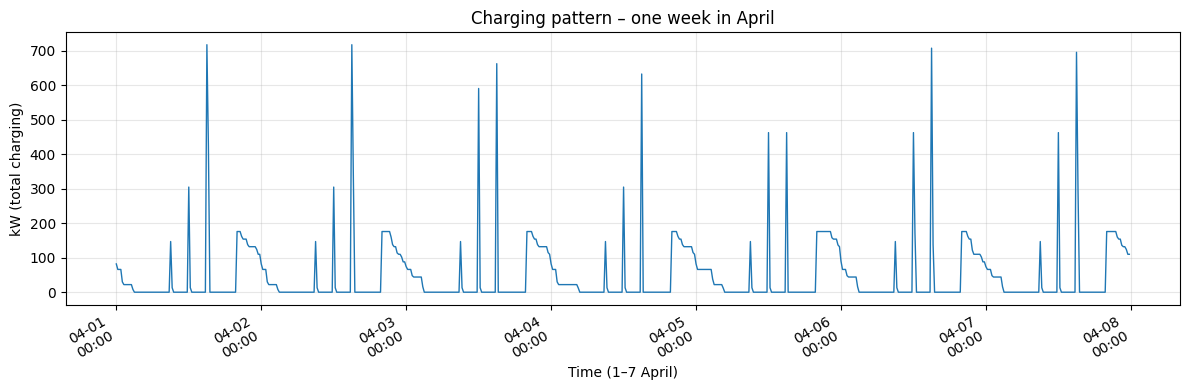

In [28]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Same base series
x_all = [i2t[i] for i in T_idx]
p_total_all = [float(sum(P[v, i].X for v in V)) for i in T_idx]

# Define one week in April (here: 1–7 April)
year = x_all[0].year  # assumes all in same year
start = dt.datetime(year, 4, 1)
end   = dt.datetime(year, 4, 8)  # exclusive upper bound

x_week = []
p_week = []
for t, p in zip(x_all, p_total_all):
    if start <= t < end:
        x_week.append(t)
        p_week.append(p)

plt.figure(figsize=(12, 4))
plt.plot(x_week, p_week, lw=1, color="tab:blue")

plt.ylabel("kW (total charging)")
plt.xlabel("Time (1–7 April)")
plt.title("Charging pattern – one week in April")
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

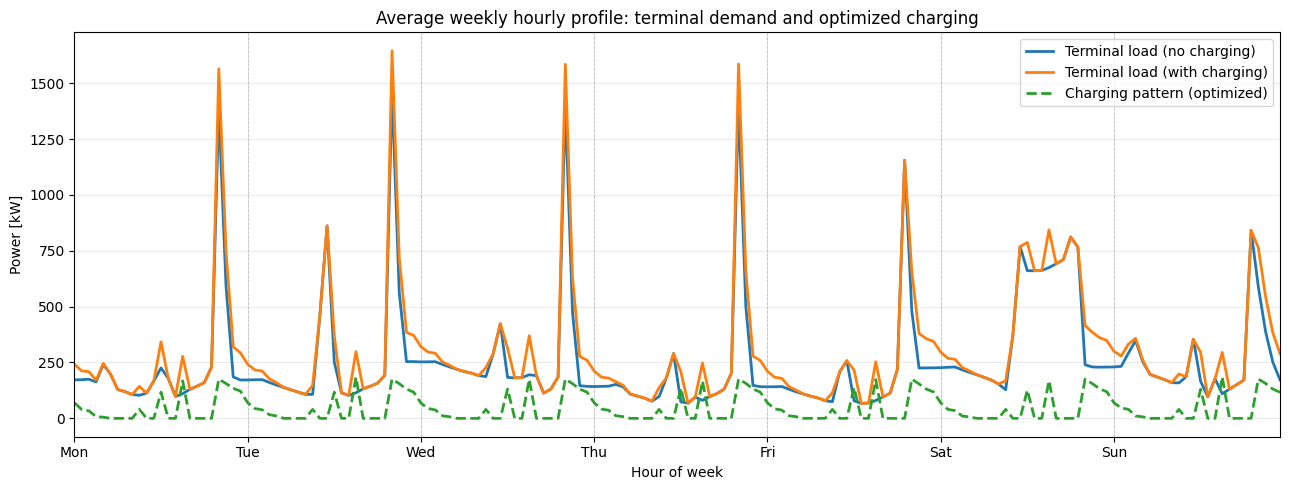

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REQUIRED_COLS = (
    "datetime",
    "base_demand_kw",
    "shore_power_demand_kw",
    "total_kW",
)


def load_optimization_results():
    if "out_df" in globals():
        candidate = out_df.copy()
        if all(col in candidate.columns for col in REQUIRED_COLS):
            return candidate

    notebook_dir = None
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        notebook_dir = Path(nb_file).resolve().parent

    search_paths = []
    if "output_file" in globals():
        search_paths.append(Path(output_file))
    if notebook_dir is not None:
        search_paths.append(notebook_dir / "outputs" / "dumb_ferryterminal_loadshifting.xlsx")

    seen = set()
    for path in search_paths:
        resolved = path.expanduser()
        if not resolved.is_absolute() and notebook_dir is not None:
            resolved = notebook_dir / resolved
        resolved = resolved.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if not resolved.is_file():
            continue

        candidate = pd.read_excel(resolved)
        missing = [col for col in REQUIRED_COLS if col not in candidate.columns]
        if missing:
            raise KeyError(
                f"{resolved} is missing columns {missing}. Found: {list(candidate.columns)}"
            )
        return candidate

    raise RuntimeError(
        "Optimization export not found. Run the results export cell first, "
        "or place dumb_ferryterminal_loadshifting.xlsx in the outputs/ folder next to this notebook."
    )


df_opt = load_optimization_results()

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")

# 2) Terminal load with and without optimized EV charging
df_opt["terminal_load_no_charging_kw"] = (
    df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
)
df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Hour of week (0..167)
df_opt["hour_of_week"] = df_opt["datetime"].dt.dayofweek * 24 + df_opt["datetime"].dt.hour

# 4) Weekly average profiles
weekly = (
    df_opt.groupby("hour_of_week")[[
        "terminal_load_no_charging_kw",
        "terminal_load_with_charging_kw",
        "charging_kw"
    ]]
    .mean()
    .reindex(range(168))
    .reset_index()
)

# 5) Plot combined
plt.figure(figsize=(13, 5))

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_no_charging_kw"],
    label="Terminal load (no charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_with_charging_kw"],
    label="Terminal load (with charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["charging_kw"],
    label="Charging pattern (optimized)",
    linewidth=2,
    linestyle="--"
)

# Day separators
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Power [kW]")
plt.title("Average weekly hourly profile: terminal demand and optimized charging")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

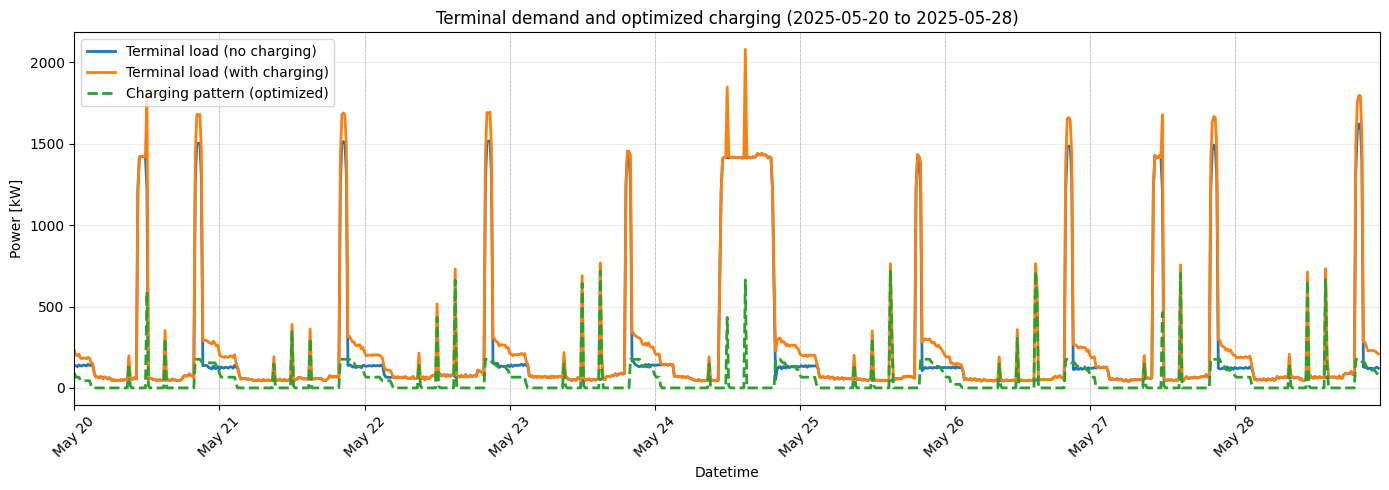

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

if "df_opt" not in globals() or "terminal_load_with_charging_kw" not in df_opt.columns:
    df_opt = load_optimization_results()
    df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
    df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")
    df_opt["terminal_load_no_charging_kw"] = (
        df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
    )
    df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
    df_opt["charging_kw"] = (
        df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
    ).clip(lower=0)

# Filter exact period (inclusive start, inclusive end date)
start = pd.Timestamp("2025-05-20 00:00:00")
end   = pd.Timestamp("2025-05-28 23:59:59")
period = df_opt[(df_opt["datetime"] >= start) & (df_opt["datetime"] <= end)].copy()

if period.empty:
    print("No data found in the selected period.")
else:
    plt.figure(figsize=(14, 5))

    plt.plot(
        period["datetime"],
        period["terminal_load_no_charging_kw"],
        label="Terminal load (no charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["terminal_load_with_charging_kw"],
        label="Terminal load (with charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["charging_kw"],
        label="Charging pattern (optimized)",
        linewidth=2,
        linestyle="--"
    )

    # Day separators + daily ticks
    day_starts = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
    for x in day_starts:
        plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

    plt.xticks(day_starts, [d.strftime("%b %d") for d in day_starts], rotation=45)
    plt.xlim(start, end)
    plt.xlabel("Datetime")
    plt.ylabel("Power [kW]")
    plt.title("Terminal demand and optimized charging (2025-05-20 to 2025-05-28)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

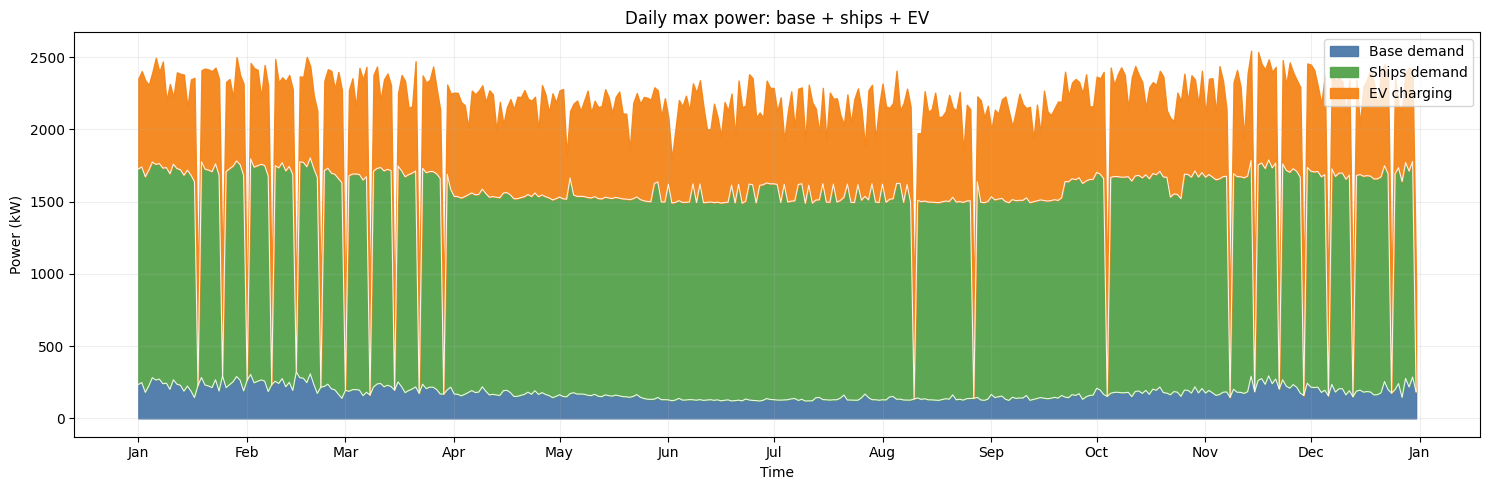

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "outputs/dumb_ferryterminal_loadshifting.xlsx"

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Daily aggregation
d = (df.set_index(TIME_COL)[[BASE_COL, SHIP_COL, EV_COL]]
       .resample("D").max()
       .reset_index())

# Cumulative levels
base_top = d[BASE_COL]
ship_top = d[BASE_COL] + d[SHIP_COL]
total    = d[BASE_COL] + d[SHIP_COL] + d[EV_COL]

fig, ax = plt.subplots(figsize=(15, 5))

# Level 1: base
ax.fill_between(d[TIME_COL], 0, base_top, color="#4C78A8", alpha=0.95, label="Base demand")

# Level 2: ships
ax.fill_between(d[TIME_COL], base_top, ship_top, color="#54A24B", alpha=0.95, label="Ships demand")

# Level 3: EV
ax.fill_between(d[TIME_COL], ship_top, total, color="#F58518", alpha=0.95, label="EV charging")

# Optional separators
ax.plot(d[TIME_COL], base_top, color="white", lw=0.8, alpha=0.9)
ax.plot(d[TIME_COL], ship_top, color="white", lw=0.8, alpha=0.9)

ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Daily max power: base + ships + EV")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


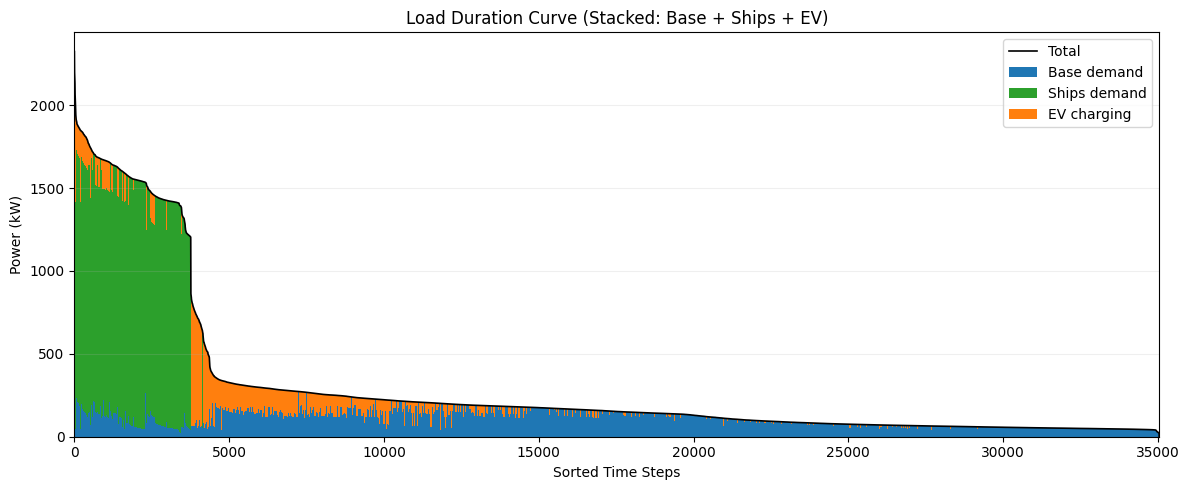

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
file_path = "outputs/dumb_ferryterminal_loadshifting.xlsx"
sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL],   errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[SHIP_COL] + tmp[EV_COL]

# Sort descending by total load (duration curve)
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# x = sorted time-step index
x = np.arange(len(tmp))

base_sorted  = tmp[BASE_COL].values
ship_sorted  = tmp[SHIP_COL].values
ev_sorted    = tmp[EV_COL].values
base_ship_top = base_sorted + ship_sorted
total_sorted = tmp["total"].values

# ----------------------------
# Plot (stacked, striped style)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Layer 1: base
ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)

# Layer 2: ships (on top of base)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)

# Layer 3: EV (on top of base+ships)
ax.bar(x, ev_sorted, width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)

# Top envelope line
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve (Stacked: Base + Ships + EV)")
ax.set_xlabel("Sorted Time Steps")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(0, total_sorted.max() * 1.05)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

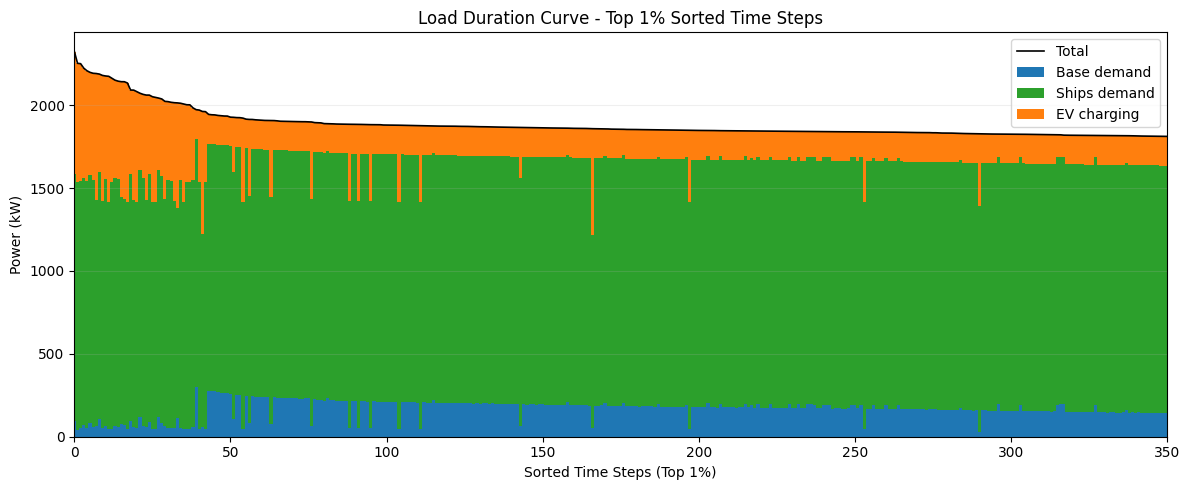

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
file_path = "outputs/dumb_ferryterminal_loadshifting.xlsx"
sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[SHIP_COL] + tmp[EV_COL]
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# Keep only top 1% sorted timesteps
n = len(tmp)
top_n = max(1, int(np.ceil(0.01 * n)))
top = tmp.iloc[:top_n].copy()

x = np.arange(top_n)
base_sorted = top[BASE_COL].values
ship_sorted = top[SHIP_COL].values
ev_sorted   = top[EV_COL].values
base_ship_top = base_sorted + ship_sorted
total_sorted = top["total"].values

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)
ax.bar(x, ev_sorted,   width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve - Top 1% Sorted Time Steps")
ax.set_xlabel("Sorted Time Steps (Top 1%)")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, top_n - 1)
ax.set_ylim(0, total_sorted.max() * 1.05)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


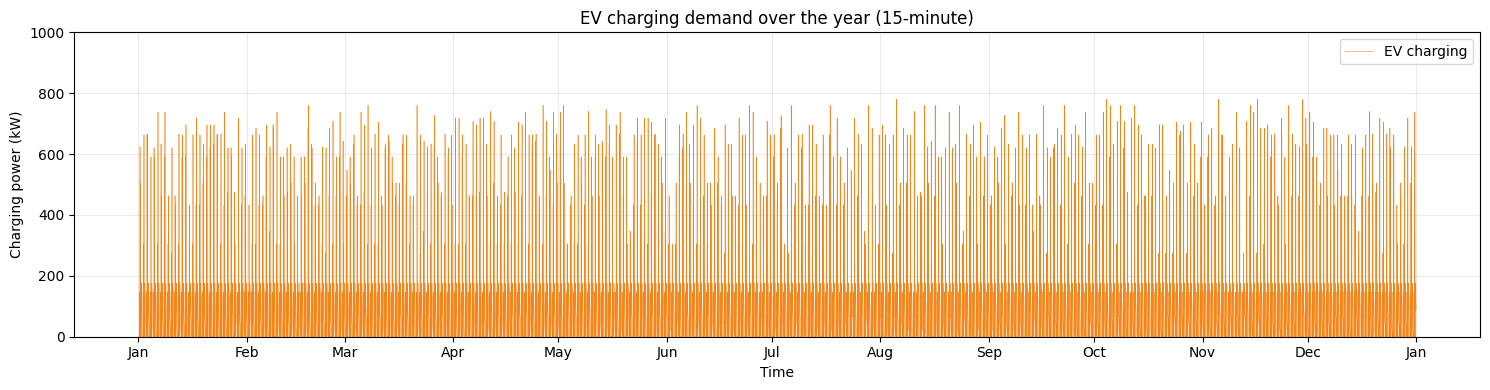

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TIME_COL = "datetime"
EV_COL = "EV_charging_kw"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)
df[EV_COL] = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Full year (15-min)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df[TIME_COL], df[EV_COL], linewidth=0.4, color="#F58518", label="EV charging")
ax.set_ylim(0, 2500)
ax.set_ylabel("Charging power (kW)")
ax.set_xlabel("Time")
ax.set_title("EV conventional charging demand over the year (15-minute)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.25)
ax.set_ylim(0, 1000)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Selected week: 2025-10-13/2025-10-19 (price range = 5.494 EUR/kWh)


/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/ipykernel_16678/1654387671.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/ipykernel_16678/1654387671.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/ipykernel_16678/1654387671.py:19: SettingWithCopyWarning: 
A value is 

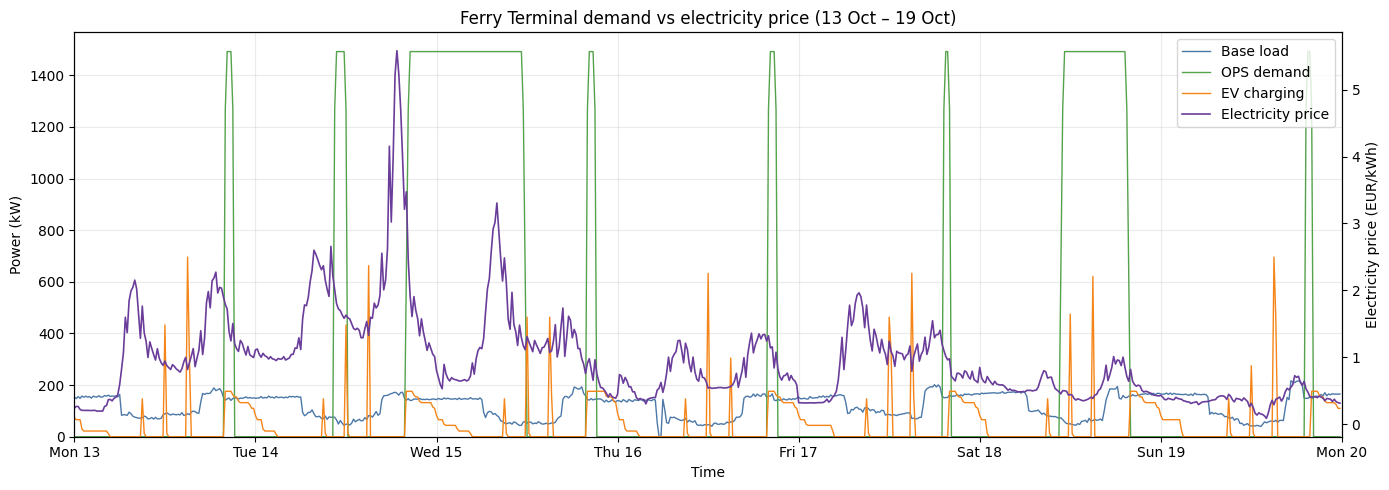

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
OPS_COL = "shore_power_demand_kw"
EV_COL = "EV_charging_kw"
PRICE_COL = "da_price"

# Load demand components
if "out_df" in globals():
    df = out_df[[TIME_COL, BASE_COL, OPS_COL, EV_COL]]
else:
    df = pd.read_excel(file_path)[[TIME_COL, BASE_COL, OPS_COL, EV_COL]]

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
for col in [BASE_COL, OPS_COL, EV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

# Load electricity price
price = da_price[[TIME_COL, PRICE_COL]].copy()
price[TIME_COL] = pd.to_datetime(price[TIME_COL], errors="coerce")
price[PRICE_COL] = pd.to_numeric(price[PRICE_COL], errors="coerce")

plot_df = df.merge(price, on=TIME_COL, how="inner").sort_values(TIME_COL)

# Pick week with largest price fluctuation
plot_df["week"] = plot_df[TIME_COL].dt.to_period("W-SUN")
week_stats = plot_df.groupby("week")[PRICE_COL].agg(lambda s: s.max() - s.min())
selected_week = week_stats.idxmax()
print(f"Selected week: {selected_week} (price range = {week_stats.max():.3f} EUR/kWh)")

week_df = plot_df[plot_df["week"] == selected_week].copy()
start = week_df[TIME_COL].min()
end = week_df[TIME_COL].max() + pd.Timedelta(minutes=15)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(week_df[TIME_COL], week_df[BASE_COL], color="#4C78A8", linewidth=1.0, label="Base load")
ax1.plot(week_df[TIME_COL], week_df[OPS_COL], color="#54A24B", linewidth=1.0, label="OPS demand")
ax1.plot(week_df[TIME_COL], week_df[EV_COL], color="#F58518", linewidth=1.0, label="EV charging")

ax1.set_ylabel("Power (kW)")
power_max = week_df[[BASE_COL, OPS_COL, EV_COL]].max().max()
ax1.set_ylim(0, max(1000, power_max * 1.05))
ax1.set_xlabel("Time")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(week_df[TIME_COL], week_df[PRICE_COL], color="#6A3D9A", linewidth=1.2, label="Electricity price")
ax2.set_ylabel("Electricity price (EUR/kWh)")

ax1.set_title(f"Ferry Terminal demand vs electricity price ({start:%d %b} – {end - pd.Timedelta(days=1):%d %b})")
ax1.set_xlim(start, end)
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()